# Ames Housing: Exploratory Data Analysis

This notebook is where the data gets explored before any modelling happens. The
rest of the project (`data_cleaning.py`, `feature_selection.py`, `model_training.py`) makes a lot
of decisions, and this is where those decisions get justified.

The idea is to look at the raw data first and let it answer some basic questions:

* What are we predicting, and what does it look like?
* Which missing values are actually missing, and which just mean the house
  doesn't have that thing?
* Which features actually affect the price?
* Why does it make sense to transform the target and build the features we build?

We load the raw dataset (`AmesHousing.csv`) on purpose, before any cleaning,
because the whole point is to show the reasoning that leads to the cleaning and
feature choices later on.

## 1. Setup and a first look

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # keep output tidy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Load the raw data exactly as it arrives, before any cleaning.
df = pd.read_csv("data/raw/AmesHousing.csv")
print(f"Shape: {df.shape[0]} houses, {df.shape[1]} columns")
df.head()

Shape: 2930 houses, 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


There are about 2,930 houses and 82 columns. Most columns describe a house, and
one of them, `SalePrice`, is the thing we want to predict.

Let's split the columns into numeric and categorical, since the two types get
handled very differently later.

In [2]:
numeric = df.select_dtypes(include="number").columns.tolist()
# "categorical" is just everything that isn't numeric. Defining it this way
# avoids a pandas version quirk around how string columns are detected.
categorical = [c for c in df.columns if c not in numeric]

print(f"Numeric columns:     {len(numeric)}")
print(f"Categorical columns: {len(categorical)}")
print()
print("A few numeric:", numeric[:8])
print("A few categorical:", categorical[:8])

Numeric columns:     39
Categorical columns: 43

A few numeric: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built']
A few categorical: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope']


## 2. The target: SalePrice

Before anything else, it's worth understanding the thing we're predicting. The
way prices are distributed has a direct effect on how we should model them.

In [3]:
price = df["SalePrice"]
print(price.describe().round(0))
print(f"\nSkewness: {price.skew():.2f}  (0 means symmetric, above 1 means a strong right skew)")

count      2930.0
mean     180796.0
std       79887.0
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0
Name: SalePrice, dtype: float64

Skewness: 1.74  (0 means symmetric, above 1 means a strong right skew)


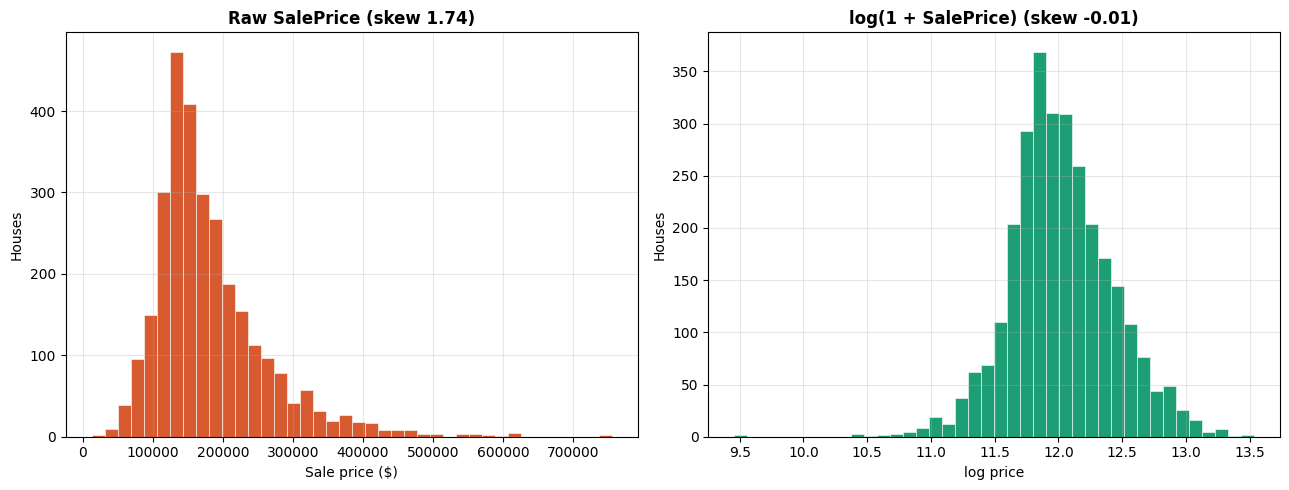

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw price is right-skewed
axes[0].hist(price, bins=40, color="#D85A30", edgecolor="white", lw=0.4)
axes[0].set_title(f"Raw SalePrice (skew {price.skew():.2f})", fontweight="bold")
axes[0].set_xlabel("Sale price ($)"); axes[0].set_ylabel("Houses")

# Log price is symmetric
log_price = np.log1p(price)
axes[1].hist(log_price, bins=40, color="#1D9E75", edgecolor="white", lw=0.4)
axes[1].set_title(f"log(1 + SalePrice) (skew {log_price.skew():.2f})", fontweight="bold")
axes[1].set_xlabel("log price"); axes[1].set_ylabel("Houses")

plt.tight_layout(); plt.show()

This one chart is the reason the pipeline trains on the log of the price.

The raw prices on the left are heavily right-skewed. There's a big group of
affordable houses and a long tail of expensive ones. After taking `log1p`, the
distribution on the right is almost perfectly symmetric, with the skew dropping
from about 1.7 to roughly 0.

This matters for two reasons:

1. **Fairer errors.** On raw prices, being off by 30k on a 100k house is a 30%
   disaster, but being off by that same 30k on a 700k house is only 4% and
   fairly harmless. The model treats both the same. Working in log space makes
   the model care about percentage error instead, which is what actually
   matters.

2. **Prices behave multiplicatively.** A garage adds roughly a percentage to a
   house's value, not a flat dollar amount. Taking the log turns those
   multiplicative effects into additive ones, which is the form a regression
   model can actually fit.

So the pipeline trains on `log1p(SalePrice)` and converts predictions back with
`expm1`. This chart is the evidence for that.

## 3. Missing data, and why most of it isn't really missing

The raw data has a lot of nulls. But there's an important point hiding here:
most of them don't mean the data failed to record. They mean the house simply
doesn't have that feature.

In [5]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(f"{len(nulls)} columns contain nulls. The worst ones:\n")
print((nulls.head(12) / len(df) * 100).round(1).astype(str) + "%  (" +
      nulls.head(12).astype(str) + " rows)")

27 columns contain nulls. The worst ones:

Pool QC          99.6%  (2917 rows)
Misc Feature     96.4%  (2824 rows)
Alley            93.2%  (2732 rows)
Fence            80.5%  (2358 rows)
Mas Vnr Type     60.6%  (1775 rows)
Fireplace Qu     48.5%  (1422 rows)
Lot Frontage      16.7%  (490 rows)
Garage Qual        5.4%  (159 rows)
Garage Cond        5.4%  (159 rows)
Garage Yr Blt      5.4%  (159 rows)
Garage Finish      5.4%  (159 rows)
Garage Type        5.4%  (157 rows)
dtype: str


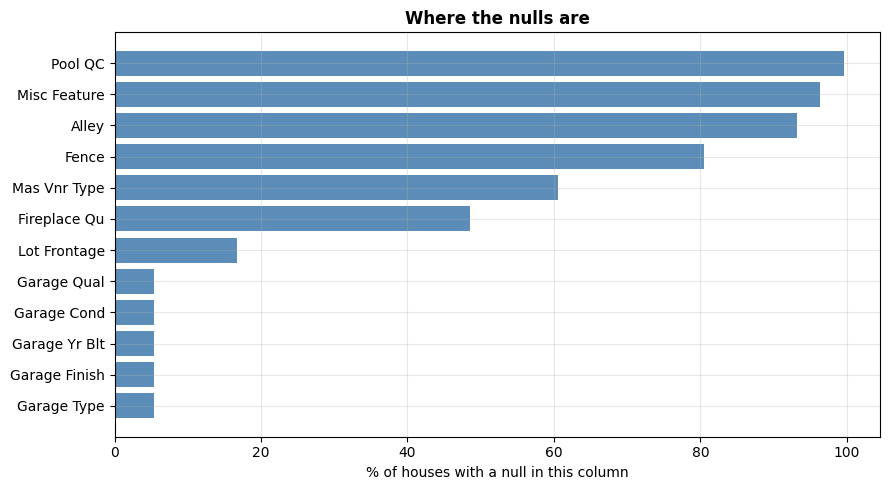

In [6]:
top_null = (nulls.head(12) / len(df) * 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_null.index[::-1], top_null.values[::-1], color="#5B8DB8")
ax.set_xlabel("% of houses with a null in this column")
ax.set_title("Where the nulls are", fontweight="bold")
plt.tight_layout(); plt.show()

Look at the worst offenders: `Pool QC`, `Misc Feature`, `Alley`, `Fence`,
`Fireplace Qu`, and the various `Garage` and `Bsmt` columns. These aren't
recording failures. They're null because the house has no pool, no alley, no
fence, no fireplace, no garage, or no basement.

This is probably the single most important cleaning insight, and it's what
drives `data_cleaning.py`:

* For these columns, a null means "the feature isn't there", so we fill it with
  `"None"` for text columns or `0` for numbers. We don't impute it.
* Only genuinely missing values (like a couple of `Lot Frontage` or
  `Electrical` entries) actually get imputed.

If we treated "absent" as "missing" and blindly imputed, we'd be inventing
garages and pools that don't exist. That's a quiet but serious mistake, and EDA
is where you catch it.

## 4. What actually drives the price?

Now the main question for any predictor: which features move the price the most?
We can start with the numeric correlations.

In [7]:
corr = df[numeric].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print("Top 12 positive correlations with SalePrice:\n")
print(corr.head(12).round(3))

Top 12 positive correlations with SalePrice:

Overall Qual      0.799
Gr Liv Area       0.707
Garage Cars       0.648
Garage Area       0.640
Total Bsmt SF     0.632
1st Flr SF        0.622
Year Built        0.558
Full Bath         0.546
Year Remod/Add    0.533
Garage Yr Blt     0.527
Mas Vnr Area      0.508
TotRms AbvGrd     0.495
Name: SalePrice, dtype: float64


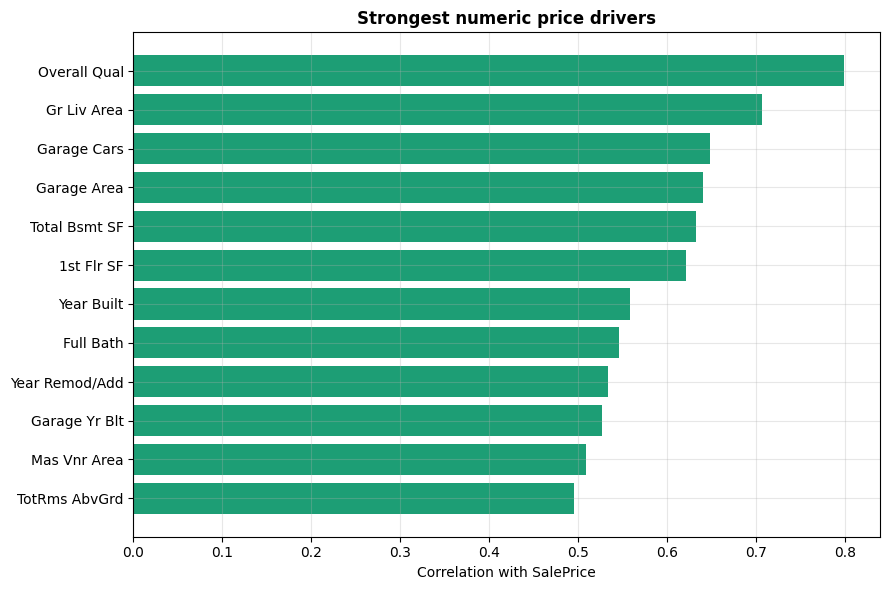

In [8]:
top = corr.head(12)[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color="#1D9E75")
ax.set_xlabel("Correlation with SalePrice")
ax.set_title("Strongest numeric price drivers", fontweight="bold")
plt.tight_layout(); plt.show()

`Overall Qual` comes out on top, followed by a group of size measures like
`Gr Liv Area`, the garage columns, `Total Bsmt SF`, and `1st Flr SF`. Two things
stand out that shape the feature engineering:

1. **Quality and size dominate.** This is why the pipeline keeps `Overall Qual`
   and builds `TotalSF` (basement plus first plus second floor) to capture total
   space in a single strong feature.

2. **Several size columns overlap.** `Garage Cars` and `Garage Area` say almost
   the same thing, and so do `1st Flr SF` and `Gr Liv Area`. That overlap is
   what `feature_selection.py` trims by keeping the more informative one of each pair.

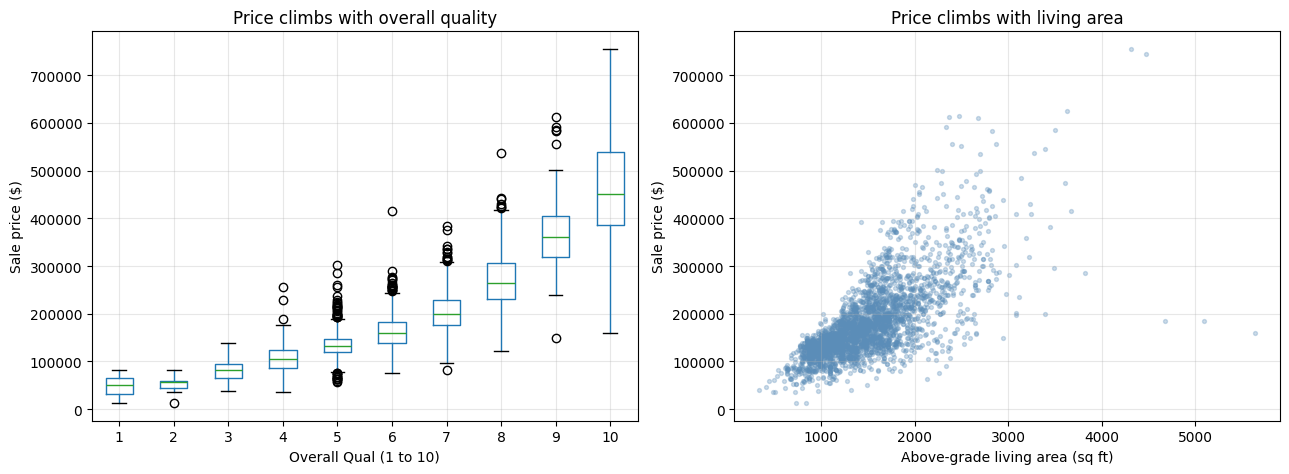

In [9]:
# Look at the two biggest drivers directly against price.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall Qual is ordinal, so a boxplot per level reads best
df.boxplot(column="SalePrice", by="Overall Qual", ax=axes[0])
axes[0].set_title("Price climbs with overall quality")
axes[0].set_xlabel("Overall Qual (1 to 10)"); axes[0].set_ylabel("Sale price ($)")

# Gr Liv Area is continuous, so a scatter works
axes[1].scatter(df["Gr Liv Area"], df["SalePrice"], s=8, alpha=0.3, color="#5B8DB8")
axes[1].set_title("Price climbs with living area")
axes[1].set_xlabel("Above-grade living area (sq ft)"); axes[1].set_ylabel("Sale price ($)")

plt.suptitle(""); plt.tight_layout(); plt.show()

Both relationships are strong and go in the direction you'd expect. One thing to
notice: there are a few very large houses in the bottom right of the scatter
that sold cheaply. These are known oddities in the Ames data (partial sales and
unusual circumstances), and they're a good reason not to assume a perfectly
straight-line fit.

## 5. Location and the neighbourhood effect

"Location, location, location." `Neighborhood` is a text column so it won't show
up in the correlation table, but it's one of the strongest signals in the data.

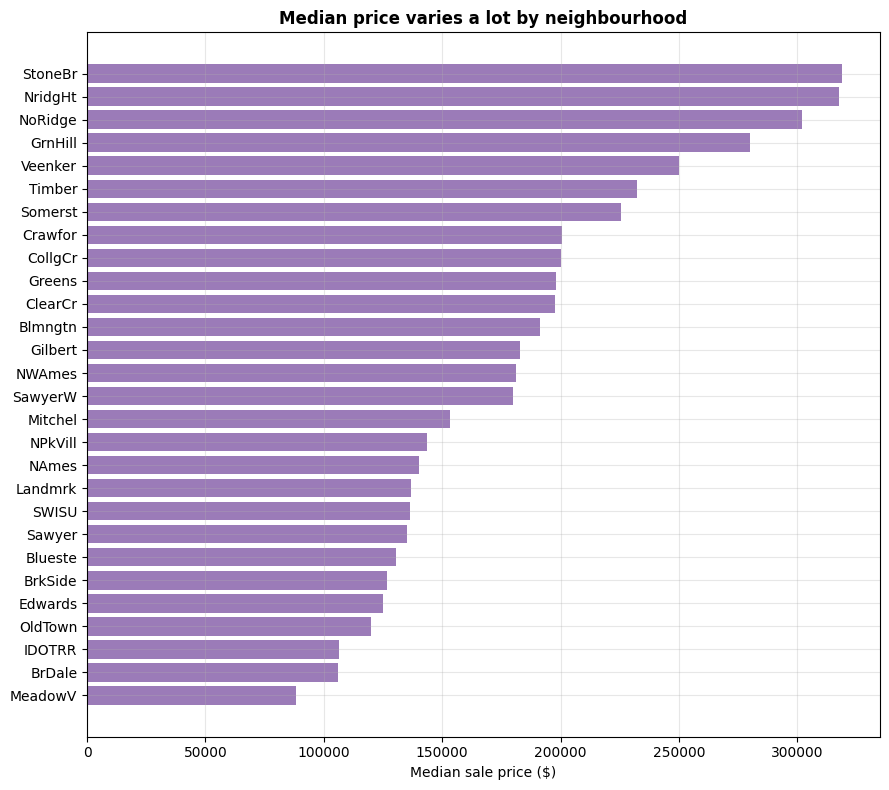

Cheapest:  MeadowV      $88,250
Priciest:  StoneBr      $319,000
Ratio:     3.6x


In [10]:
nbhd = df.groupby("Neighborhood")["SalePrice"].median().sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(nbhd.index, nbhd.values, color="#9B7BB8")
ax.set_xlabel("Median sale price ($)")
ax.set_title("Median price varies a lot by neighbourhood", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Cheapest:  {nbhd.index[0]:12s} ${nbhd.iloc[0]:,.0f}")
print(f"Priciest:  {nbhd.index[-1]:12s} ${nbhd.iloc[-1]:,.0f}")
print(f"Ratio:     {nbhd.iloc[-1] / nbhd.iloc[0]:.1f}x")

The median price is roughly 3 to 4 times higher in the most expensive
neighbourhoods than the cheapest. That's why `Neighborhood` is kept and one-hot
encoded in `feature_selection.py`, since it's one of the best predictors available. It's
also why we impute `Lot Frontage` using the median for each neighbourhood rather
than one global median, since frontage tends to vary by area.

## 6. Overlap between features

We already spotted that some size columns say the same thing. Here it is
directly, as a correlation heatmap of the main numeric features. Strong
correlations between two predictors (not just between a predictor and the price)
point to redundancy that the pipeline should trim.

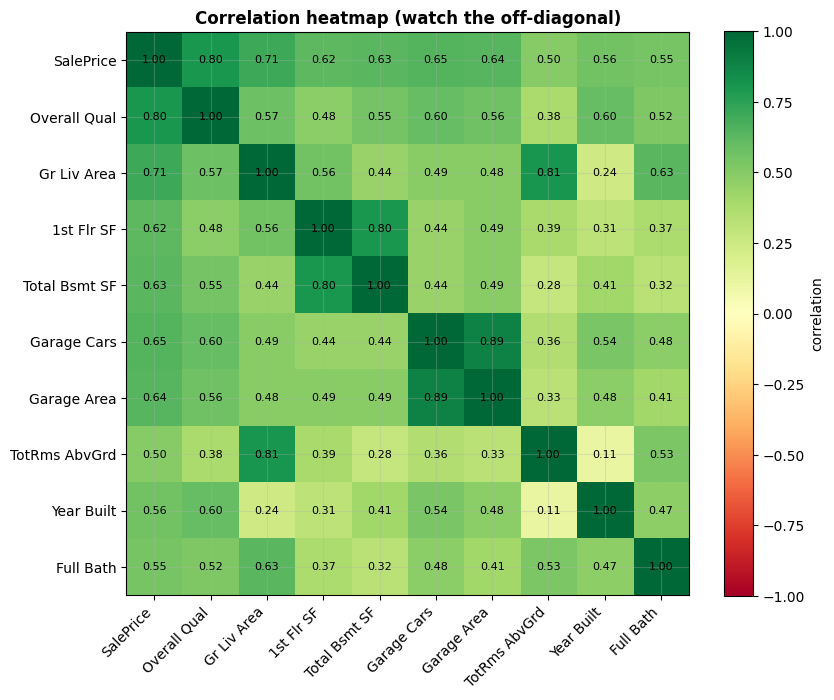

In [11]:
key_feats = ["SalePrice", "Overall Qual", "Gr Liv Area", "1st Flr SF",
             "Total Bsmt SF", "Garage Cars", "Garage Area", "TotRms AbvGrd",
             "Year Built", "Full Bath"]
cm = df[key_feats].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(key_feats))); ax.set_xticklabels(key_feats, rotation=45, ha="right")
ax.set_yticks(range(len(key_feats))); ax.set_yticklabels(key_feats)
for i in range(len(key_feats)):
    for j in range(len(key_feats)):
        ax.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center",
                color="black", fontsize=8)
fig.colorbar(im, label="correlation")
ax.set_title("Correlation heatmap (watch the off-diagonal)", fontweight="bold")
plt.tight_layout(); plt.show()

The off-diagonal cells are the interesting part:

* `Garage Cars` and `Garage Area` are about 0.89, so they measure the same
  thing.
* `Gr Liv Area` and `TotRms AbvGrd` are about 0.81, which makes sense since
  bigger houses have more rooms.
* `1st Flr SF` and `Total Bsmt SF` are related through the footprint.

Keeping both of each pair would feed the model duplicated information, make the
linear-model coefficients unstable, and blur the feature importances. This is
the direct reason for the redundancy drops in `feature_selection.py`, where we keep
`Garage Area` and drop `Garage Cars`, fold the floor areas into `TotalSF`, and
so on.

## 7. Why the engineered features make sense

EDA also gives a preview of the feature engineering. Here are two quick checks
showing the derived features carry real signal.

In [12]:
# TotalSF is basement + first floor + second floor, so total space in one column
tmp = df.copy()
tmp["TotalSF"] = (tmp["Total Bsmt SF"].fillna(0) + tmp["1st Flr SF"]
                  + tmp["2nd Flr SF"])
tmp["HouseAge"] = tmp["Yr Sold"] - tmp["Year Built"]

print("Correlation with SalePrice:")
print(f"  TotalSF (engineered):  {tmp['TotalSF'].corr(tmp['SalePrice']):+.3f}")
print(f"  Gr Liv Area (raw):     {tmp['Gr Liv Area'].corr(tmp['SalePrice']):+.3f}")
print(f"  HouseAge (engineered): {tmp['HouseAge'].corr(tmp['SalePrice']):+.3f}")
print(f"  Year Built (raw):      {tmp['Year Built'].corr(tmp['SalePrice']):+.3f}")

Correlation with SalePrice:
  TotalSF (engineered):  +0.793
  Gr Liv Area (raw):     +0.707
  HouseAge (engineered): -0.559
  Year Built (raw):      +0.558


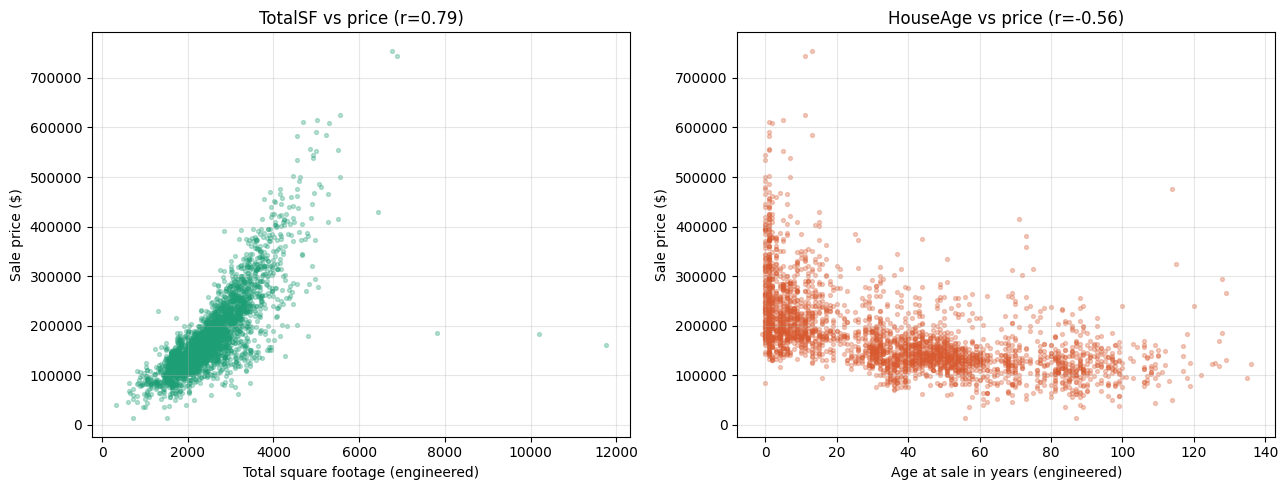

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(tmp["TotalSF"], tmp["SalePrice"], s=8, alpha=0.3, color="#1D9E75")
axes[0].set_title(f"TotalSF vs price (r={tmp['TotalSF'].corr(tmp['SalePrice']):.2f})")
axes[0].set_xlabel("Total square footage (engineered)"); axes[0].set_ylabel("Sale price ($)")

axes[1].scatter(tmp["HouseAge"], tmp["SalePrice"], s=8, alpha=0.3, color="#D85A30")
axes[1].set_title(f"HouseAge vs price (r={tmp['HouseAge'].corr(tmp['SalePrice']):.2f})")
axes[1].set_xlabel("Age at sale in years (engineered)"); axes[1].set_ylabel("Sale price ($)")

plt.tight_layout(); plt.show()

`TotalSF` ends up correlating with price even more strongly than any single raw
size column, because combining the basement and both floors concentrates the
signal. `HouseAge` shows a clean downward trend, where older houses tend to sell
for less (with some character exceptions), and it's much easier for a model to
use than the raw `Year Built` year.

That's the justification for building those features in `feature_selection.py`.

## 8. Summary

The exploration lines up with every major decision in the pipeline:

| What the data showed | What the pipeline does |
|---|---|
| SalePrice is right-skewed, and prices are multiplicative | Train on `log1p(SalePrice)` |
| Most nulls mean the feature is absent, not missing | Fill with `None` or `0`, only impute real gaps |
| Overall quality and size drive the price | Keep quality, build `TotalSF` |
| Several size columns are redundant | Drop the weaker one of each pair |
| Neighbourhood swings the price 3 to 4 times | Keep and one-hot encode, impute frontage by area |
| Raw years are awkward, age is cleaner | Build `HouseAge` and `RemodAge` |

The takeaway is that EDA isn't a box-ticking exercise. It's the evidence behind
the whole project. Any time someone asks "why did you do that?" about the
pipeline, the answer is in one of the charts above.